In [7]:
import pandas as pd

df = pd.read_csv("raw/diabetic_data.csv")
print(df.shape)
df.head()

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [8]:
# missing values aur target variable ki poori picture dekhna.

In [9]:
# Missing values check (? ko NaN samjho)
import numpy as np
df_check = df.replace('?', np.nan)
missing_summary = df_check.isnull().sum().sort_values(ascending=False)
print(missing_summary[missing_summary > 0])

# Target variable distribution
print("\nReadmitted distribution:")
print(df['readmitted'].value_counts())

weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

Readmitted distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


In [10]:
# Columns drop karo jo bahut zyada missing hain
df_clean = df.drop(columns=['weight', 'max_glu_serum', 'payer_code'])

# A1Cresult ko feature mein convert karo (test liya gaya ya nahi)
df_clean['A1Ctest_done'] = df['A1Cresult'].apply(lambda x: 0 if x == '?' else 1)
df_clean = df_clean.drop(columns=['A1Cresult'])

# race aur medical_specialty ke '?' ko 'Unknown' bana do
df_clean['race'] = df_clean['race'].replace('?', 'Unknown')
df_clean['medical_specialty'] = df_clean['medical_specialty'].replace('?', 'Unknown')

# Target variable: binary bana do
df_clean['readmitted_binary'] = df_clean['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

print(df_clean.shape)
print(df_clean['readmitted_binary'].value_counts())

(101766, 48)
readmitted_binary
0    90409
1    11357
Name: count, dtype: int64


In [11]:
# Numerical columns ki list
numerical_cols = df_clean.select_dtypes(include=['int64']).columns.tolist()
print(numerical_cols)

df_clean[numerical_cols].describe()

['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'A1Ctest_done', 'readmitted_binary']


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,A1Ctest_done,readmitted_binary
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.0,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607,1.0,0.111599
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600,0.0,0.314874
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.0,0.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000,1.0,0.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000,1.0,0.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000,1.0,0.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000,1.0,1.000000


In [12]:
def map_diagnosis(code):
    if pd.isna(code) or code == '?':
        return 'Missing'
    try:
        code = float(code)
    except:
        return 'Other'  # V/E codes (external causes) yahan aa jayenge
    
    if 390 <= code <= 459 or code == 785:
        return 'Circulatory'
    elif 460 <= code <= 519 or code == 786:
        return 'Respiratory'
    elif 520 <= code <= 579 or code == 787:
        return 'Digestive'
    elif code == 250 or (250 <= code < 251):
        return 'Diabetes'
    elif 800 <= code <= 999:
        return 'Injury'
    elif 710 <= code <= 739:
        return 'Musculoskeletal'
    elif 580 <= code <= 629 or code == 788:
        return 'Genitourinary'
    elif 140 <= code <= 239:
        return 'Neoplasms'
    else:
        return 'Other'

df_clean['diag_1_cat'] = df_clean['diag_1'].apply(map_diagnosis)
df_clean['diag_2_cat'] = df_clean['diag_2'].apply(map_diagnosis)
df_clean['diag_3_cat'] = df_clean['diag_3'].apply(map_diagnosis)

print(df_clean['diag_1_cat'].value_counts())

diag_1_cat
Circulatory        30437
Other              18172
Respiratory        14423
Digestive           9475
Diabetes            8757
Injury              6974
Genitourinary       5117
Musculoskeletal     4957
Neoplasms           3433
Missing               21
Name: count, dtype: int64


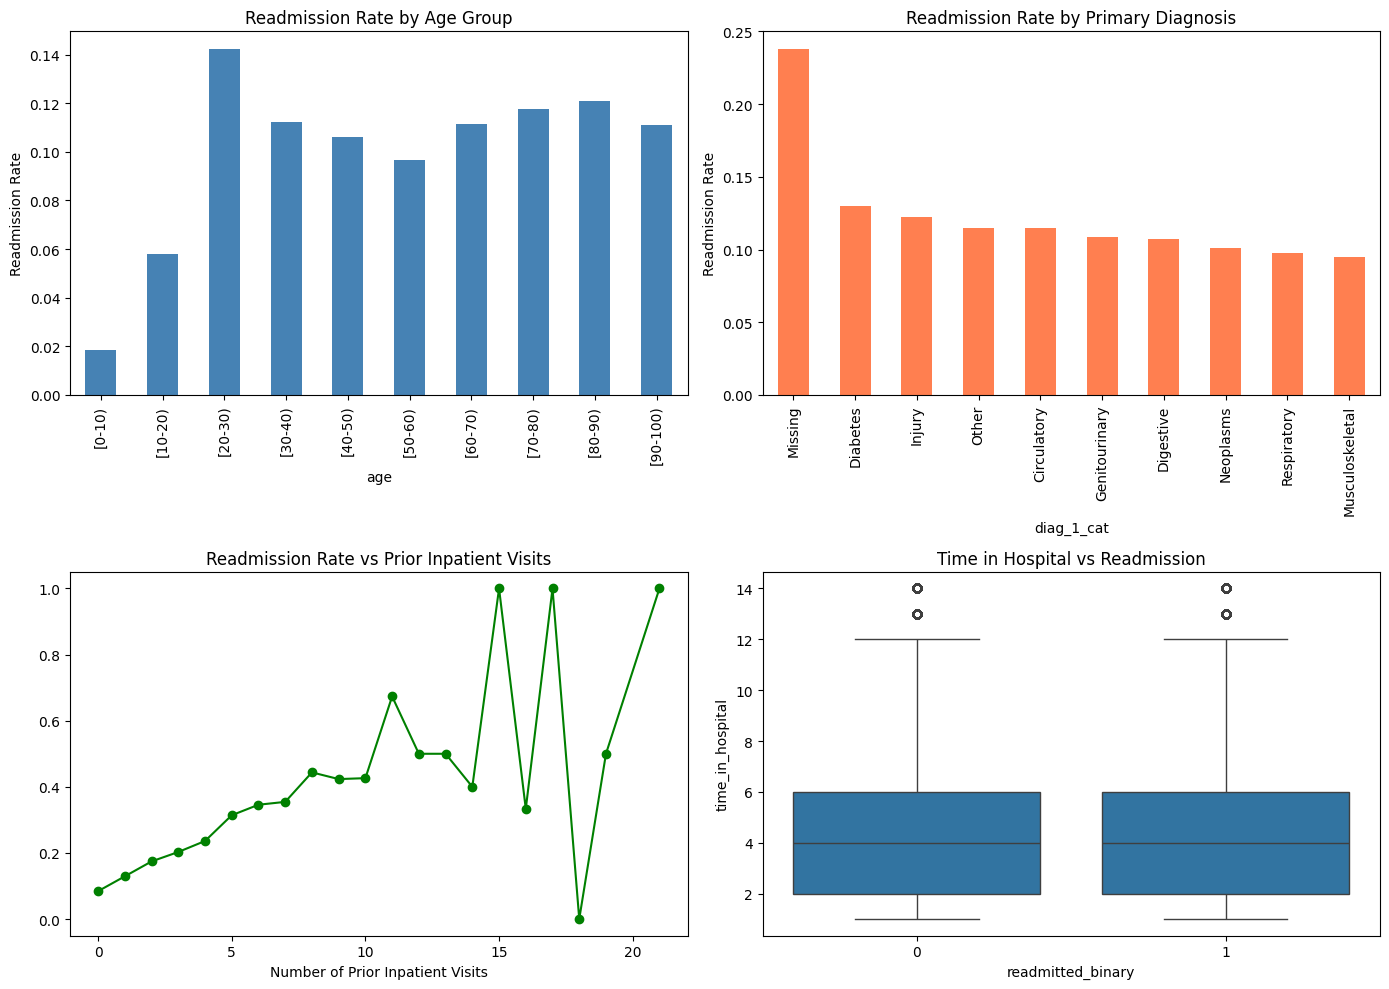

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Readmission rate by age group
age_readmit = df_clean.groupby('age')['readmitted_binary'].mean().sort_index()
age_readmit.plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Readmission Rate by Age Group')
axes[0,0].set_ylabel('Readmission Rate')

# 2. Readmission rate by primary diagnosis category
diag_readmit = df_clean.groupby('diag_1_cat')['readmitted_binary'].mean().sort_values(ascending=False)
diag_readmit.plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Readmission Rate by Primary Diagnosis')
axes[0,1].set_ylabel('Readmission Rate')

# 3. Readmission rate by number of prior inpatient visits
inpatient_readmit = df_clean.groupby('number_inpatient')['readmitted_binary'].mean()
inpatient_readmit.plot(kind='line', marker='o', ax=axes[1,0], color='green')
axes[1,0].set_title('Readmission Rate vs Prior Inpatient Visits')
axes[1,0].set_xlabel('Number of Prior Inpatient Visits')

# 4. Time in hospital distribution by readmission status
sns.boxplot(data=df_clean, x='readmitted_binary', y='time_in_hospital', ax=axes[1,1])
axes[1,1].set_title('Time in Hospital vs Readmission')

plt.tight_layout()
plt.savefig('readmission_eda_plots.png', dpi=100)
plt.show()

In [14]:
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print(categorical_cols)
for col in categorical_cols:
    print(f"\n{col}: {df_clean[col].nunique()} unique values")

['race', 'gender', 'age', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'diag_1_cat', 'diag_2_cat', 'diag_3_cat']

race: 6 unique values

gender: 3 unique values

age: 10 unique values

medical_specialty: 73 unique values

diag_1: 717 unique values

diag_2: 749 unique values

diag_3: 790 unique values

metformin: 4 unique values

repaglinide: 4 unique values

nateglinide: 4 unique values

chlorpropamide: 4 unique values

glimepiride: 4 unique values

acetohexamide: 2 unique values

glipizide: 4 unique values

glyburide: 4 unique values

tolbutamide: 2 unique values

In [15]:
# Unnecessary columns drop karo (IDs, raw diag codes, original target, zero-variance columns)
drop_cols = ['encounter_id', 'patient_nbr', 'diag_1', 'diag_2', 'diag_3', 
             'readmitted', 'examide', 'citoglipton']
df_model = df_clean.drop(columns=drop_cols)

# medical_specialty ko simplify karo - top 10 rakho, baaki 'Other'
top_specialties = df_model['medical_specialty'].value_counts().nlargest(10).index
df_model['medical_specialty'] = df_model['medical_specialty'].apply(
    lambda x: x if x in top_specialties else 'Other'
)

print(df_model.shape)
print(df_model.dtypes.value_counts())

(101766, 43)
object    30
int64     13
Name: count, dtype: int64


In [16]:
# One-hot encoding saare categorical columns ka
df_encoded = pd.get_dummies(df_model, drop_first=True)

print(df_encoded.shape)
df_encoded.head()

(101766, 116)


,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,diag_2_cat_Respiratory,diag_3_cat_Diabetes,diag_3_cat_Digestive,diag_3_cat_Genitourinary,diag_3_cat_Injury,diag_3_cat_Missing,diag_3_cat_Musculoskeletal,diag_3_cat_Neoplasms,diag_3_cat_Other,diag_3_cat_Respiratory
0,6,25,1,1,41,0,1,0,0,0,...,False,False,False,False,False,True,False,False,False,False
1,1,1,7,3,59,0,18,0,0,0,...,False,False,False,False,False,False,False,False,True,False
2,1,1,7,2,11,5,13,2,0,1,...,False,False,False,False,False,False,False,False,True,False
3,1,1,7,2,44,1,16,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,1,1,7,1,51,0,8,0,0,0,...,False,True,False,False,False,False,False,False,False,False


In [17]:
df_encoded.to_csv('processed_diabetes_data.csv', index=False)
print("Saved successfully")
print(df_encoded.shape)

Saved successfully
(101766, 116)


In [18]:
# EDA aur feature engineering ka phase yahin complete hota hai — solid progress hai.

# Ab naya notebook banate hain, taaki EDA aur modeling alag-alag files mein clean tareeke se organized rahe.